In [1]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataframe
df = pd.read_csv('features_df.csv')
df.head()

,Query ID,Best Alpha,MRR,Character Count,Word Count,What,Where,When,Why,How,...,Index 758,Index 759,Index 760,Index 761,Index 762,Index 763,Index 764,Index 765,Index 766,Index 767
0,2,0.00,1.00,22,3,1,0,0,0,0,...,-0.055597,-0.371679,0.132870,-0.316542,0.164232,-0.089220,-0.071347,-0.031938,0.285646,0.290846
1,1048585,0.00,0.50,23,5,0,0,0,0,0,...,0.044813,-0.239406,-0.098719,-0.050720,0.171317,-0.123599,-0.302324,0.148471,0.649183,-0.100653
2,458771,0.00,1.00,26,5,0,0,0,0,0,...,0.517331,-0.523775,0.629171,0.088614,0.271708,-0.158394,-0.384479,0.177981,0.435811,-0.153385
3,163860,0.01,0.25,22,4,1,0,0,0,0,...,0.216643,-0.263777,0.258236,-0.068101,0.137655,-0.179666,-0.398831,-0.017433,0.020971,-0.071258
4,458774,0.00,0.50,23,4,0,0,0,0,0,...,-0.132631,-0.287455,0.245836,-0.133143,0.376936,-0.210180,-0.285664,0.195498,0.727291,-0.124383


In [3]:
# X and y dataframes
X = df.drop('Best Alpha', axis=1)
y = np.asarray(df['Best Alpha'], dtype="float64")

X.head()

,Query ID,MRR,Character Count,Word Count,What,Where,When,Why,How,Index 0,...,Index 758,Index 759,Index 760,Index 761,Index 762,Index 763,Index 764,Index 765,Index 766,Index 767
0,2,1.00,22,3,1,0,0,0,0,-0.062403,...,-0.055597,-0.371679,0.132870,-0.316542,0.164232,-0.089220,-0.071347,-0.031938,0.285646,0.290846
1,1048585,0.50,23,5,0,0,0,0,0,-0.093802,...,0.044813,-0.239406,-0.098719,-0.050720,0.171317,-0.123599,-0.302324,0.148471,0.649183,-0.100653
2,458771,1.00,26,5,0,0,0,0,0,-0.123280,...,0.517331,-0.523775,0.629171,0.088614,0.271708,-0.158394,-0.384479,0.177981,0.435811,-0.153385
3,163860,0.25,22,4,1,0,0,0,0,-0.097564,...,0.216643,-0.263777,0.258236,-0.068101,0.137655,-0.179666,-0.398831,-0.017433,0.020971,-0.071258
4,458774,0.50,23,4,0,0,0,0,0,0.013936,...,-0.132631,-0.287455,0.245836,-0.133143,0.376936,-0.210180,-0.285664,0.195498,0.727291,-0.124383


In [4]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Training and testing sets (CHANGE TEST SIZE?)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [6]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=300,
    random_state=42,
    verbose=True
)

In [7]:
print(y_train)

[0.01 0.   0.   ... 0.   0.   0.01]


In [8]:
# Train/fit model
mlp.fit(X_train, y_train)

# Predictions
y_pred = mlp.predict(X_test)

Iteration 1, loss = 0.14648162
Iteration 2, loss = 0.02772604
Iteration 3, loss = 0.01433583
Iteration 4, loss = 0.00929723
Iteration 5, loss = 0.00656644
Iteration 6, loss = 0.00496717
Iteration 7, loss = 0.00378270
Iteration 8, loss = 0.00305020
Iteration 9, loss = 0.00247610
Iteration 10, loss = 0.00203091
Iteration 11, loss = 0.00168755
Iteration 12, loss = 0.00141690
Iteration 13, loss = 0.00120899
Iteration 14, loss = 0.00107144
Iteration 15, loss = 0.00091998
Iteration 16, loss = 0.00079520
Iteration 17, loss = 0.00069509
Iteration 18, loss = 0.00060537
Iteration 19, loss = 0.00055629
Iteration 20, loss = 0.00050157
Iteration 21, loss = 0.00044965
Iteration 22, loss = 0.00039996
Iteration 23, loss = 0.00036716
Iteration 24, loss = 0.00034480
Iteration 25, loss = 0.00031349
Iteration 26, loss = 0.00028644
Iteration 27, loss = 0.00027047
Iteration 28, loss = 0.00024906
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Checking errors
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


MSE: 0.0266
RMSE: 0.1631
MAE: 0.1247
R²: -1494.1592


In [16]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, validation_curve
import seaborn as sns

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")
print(f"Train R2: {r2_train:.4f}, Test R2: {r2_test:.4f}")

Train MSE: 0.0004, Test MSE: 0.0266
Train R2: -0.8112, Test R2: -1494.1592


Min: -0.09296012136959544 , Max: 1.0


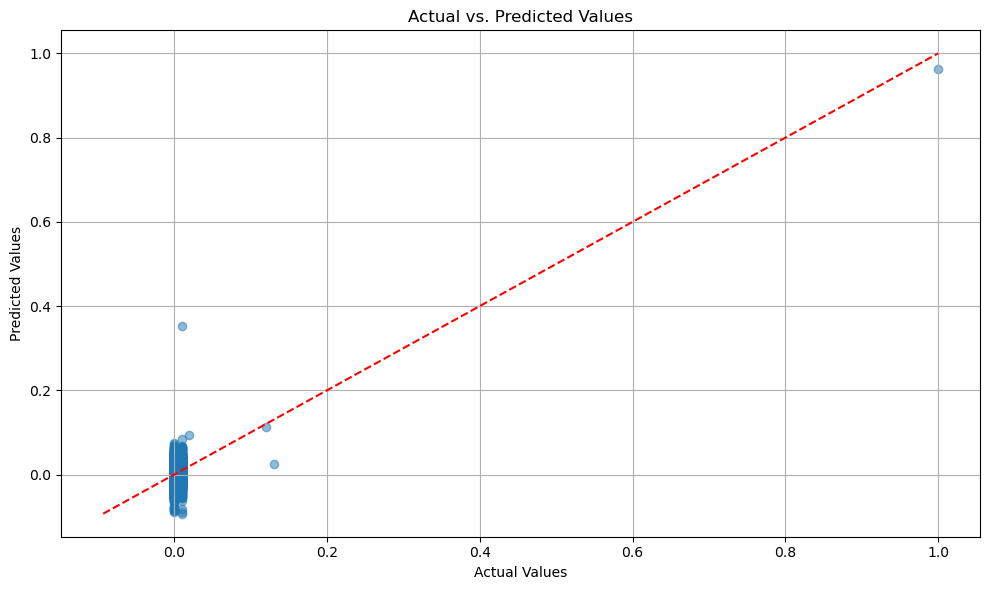

In [11]:
# Training data plot
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_pred_train, alpha=0.5)

min_val = min(min(y_train), min(y_pred_train))
max_val = max(max(y_train), max(y_pred_train))
print("Min:", min_val, ", Max:", max_val)
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.tight_layout()
plt.show()

Min: -0.7141698550048798 , Max: 0.49897628482458145


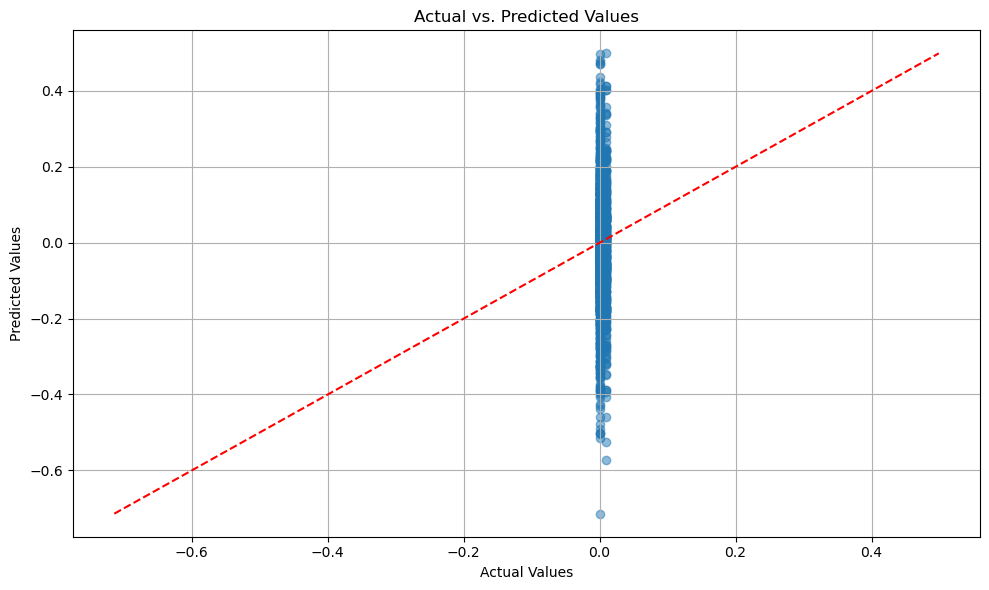

In [12]:
# Testing data plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)

min_val = min(min(y_test), min(y_pred_test))
max_val = max(max(y_test), max(y_pred_test))
print("Min:", min_val, ", Max:", max_val)
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.tight_layout()
plt.show()

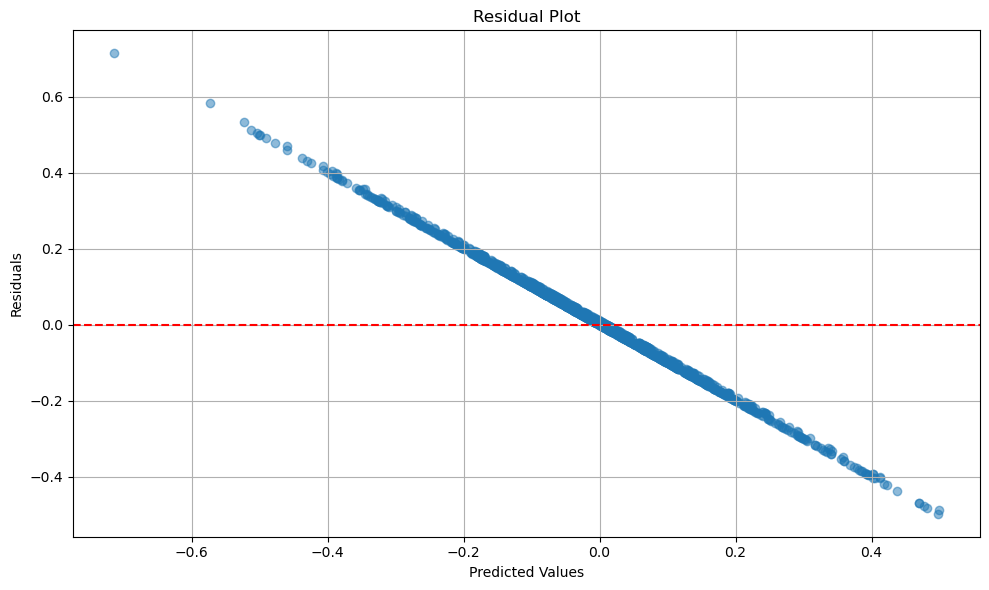

In [13]:
# Residuals plot
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


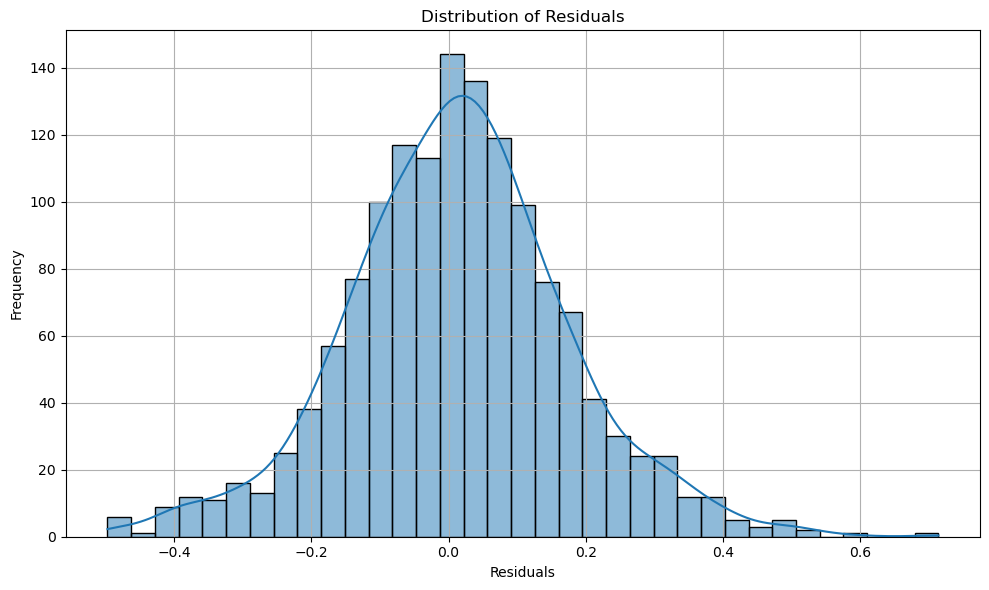

In [14]:
# Residuals distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()


Iteration 1, loss = 0.58766382
Iteration 2, loss = 0.14386857
Iteration 3, loss = 0.12361455
Iteration 4, loss = 0.07627647
Iteration 5, loss = 0.05538179
Iteration 6, loss = 0.03406114
Iteration 7, loss = 0.02301925
Iteration 8, loss = 0.02199678
Iteration 9, loss = 0.01640342
Iteration 10, loss = 0.00937960
Iteration 11, loss = 0.00763264
Iteration 12, loss = 0.00692794
Iteration 13, loss = 0.00474497
Iteration 14, loss = 0.00317144
Iteration 15, loss = 0.00254753
Iteration 16, loss = 0.00191256
Iteration 17, loss = 0.00152948
Iteration 18, loss = 0.00122533
Iteration 19, loss = 0.00087132
Iteration 20, loss = 0.00062153
Iteration 21, loss = 0.00053027
Iteration 22, loss = 0.00042362
Iteration 23, loss = 0.00031610
Iteration 24, loss = 0.00023887
Iteration 25, loss = 0.00018937
Iteration 26, loss = 0.00016598
Iteration 27, loss = 0.00013316
Iteration 28, loss = 0.00010588
Iteration 29, loss = 0.00009395
Iteration 30, loss = 0.00008455
Iteration 31, loss = 0.00007470
Iteration 32, los

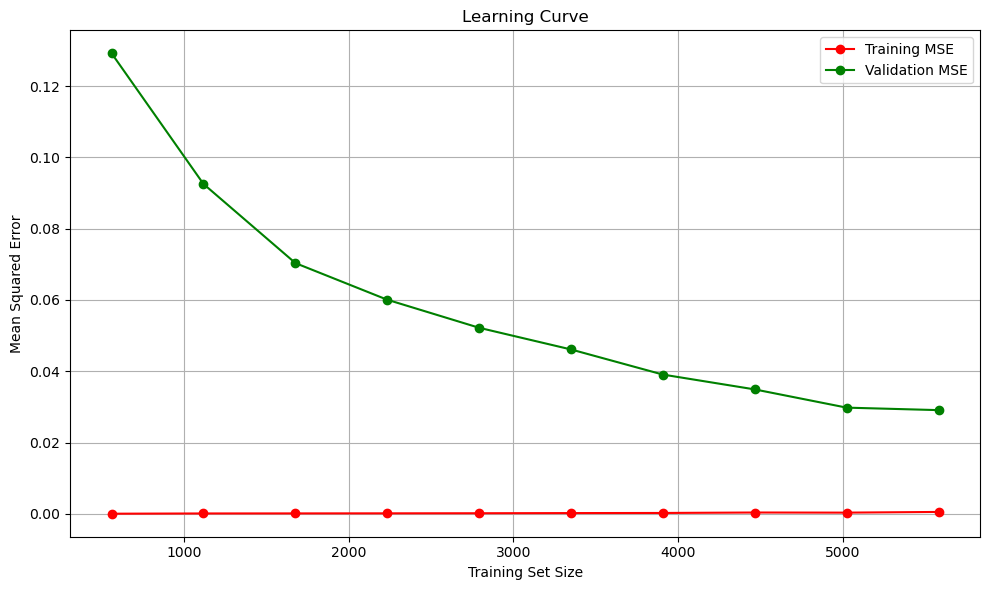

In [15]:
# Learning curve
# mlp = MLPRegressor(
#     hidden_layer_sizes=(64, 32),
#     activation='relu',
#     solver='adam',
#     alpha=0.0001,
#     batch_size='auto',
#     learning_rate='adaptive',
#     max_iter=300,
#     random_state=42,
#     verbose=True
# )

train_sizes, train_scores, test_scores = learning_curve(
    mlp, X_scaled, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='neg_mean_squared_error')

train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training MSE')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Validation MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()
